In [66]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer

In [8]:
df = pd.read_excel("Dataset for Data Analytics.xlsx")

In [10]:
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [13]:
df.describe()

,Date,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200,1200.000000,1200.000000,1200.000000,1200.000000
mean,2024-03-22 16:58:48,2.945833,356.412750,5.485000,1053.968300
min,2023-01-01 00:00:00,1.000000,11.390000,1.000000,11.390000
25%,2023-08-03 18:00:00,2.000000,186.062500,4.000000,410.520000
50%,2024-03-23 00:00:00,3.000000,364.210000,5.000000,823.615000
75%,2024-11-08 12:00:00,4.000000,521.570000,7.000000,1578.475000
max,2025-06-30 00:00:00,5.000000,699.930000,10.000000,3456.400000
std,NaN,1.407557,197.177146,2.281983,819.856558


In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   str           
 1   Date             1200 non-null   datetime64[us]
 2   CustomerID       1200 non-null   str           
 3   Product          1200 non-null   str           
 4   Quantity         1200 non-null   int64         
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   str           
 7   PaymentMethod    1200 non-null   str           
 8   OrderStatus      1200 non-null   str           
 9   TrackingNumber   1200 non-null   str           
 10  ItemsInCart      1200 non-null   int64         
 11  CouponCode       891 non-null    str           
 12  ReferralSource   1200 non-null   str           
 13  TotalPrice       1200 non-null   float64       
dtypes: datetime64[us](1), float64(2), int64(2), str(9)


In [91]:
df.isnull().sum()

OrderID                  0
Date                     0
CustomerID               0
Product                  0
Quantity                 0
UnitPrice                0
ShippingAddress          0
PaymentMethod            0
OrderStatus              0
TrackingNumber           0
ItemsInCart              0
CouponCode               0
ReferralSource           0
TotalPrice               0
UsedCoupon               0
zscore                   0
OrderMonth               0
OrderDayOfWeek           0
IsWeekend                0
CartConversionRatio      0
AvgItemPrice             0
CustomerOrderCount       0
ReferralAvgOrderValue    0
dtype: int64

In [92]:
knn_imputer = KNNImputer(n_neighbors=5)
df['CouponCode'] = knn_imputer.fit_transform(df[['CouponCode']])

In [67]:
df['CouponCode'] = df['CouponCode'].notna().astype(int)

In [93]:
df ["CouponCode"].value_counts()

CouponCode
1.0    1176
Name: count, dtype: int64

In [69]:
df.isnull().sum()

OrderID                  0
Date                     0
CustomerID               0
Product                  0
Quantity                 0
UnitPrice                0
ShippingAddress          0
PaymentMethod            0
OrderStatus              0
TrackingNumber           0
ItemsInCart              0
CouponCode               0
ReferralSource           0
TotalPrice               0
UsedCoupon               0
zscore                   0
OrderMonth               0
OrderDayOfWeek           0
IsWeekend                0
CartConversionRatio      0
AvgItemPrice             0
CustomerOrderCount       0
ReferralAvgOrderValue    0
dtype: int64

In [70]:
df["UsedCoupon"].dropna(inplace=True)

In [71]:
df.isnull().sum()

OrderID                  0
Date                     0
CustomerID               0
Product                  0
Quantity                 0
UnitPrice                0
ShippingAddress          0
PaymentMethod            0
OrderStatus              0
TrackingNumber           0
ItemsInCart              0
CouponCode               0
ReferralSource           0
TotalPrice               0
UsedCoupon               0
zscore                   0
OrderMonth               0
OrderDayOfWeek           0
IsWeekend                0
CartConversionRatio      0
AvgItemPrice             0
CustomerOrderCount       0
ReferralAvgOrderValue    0
dtype: int64

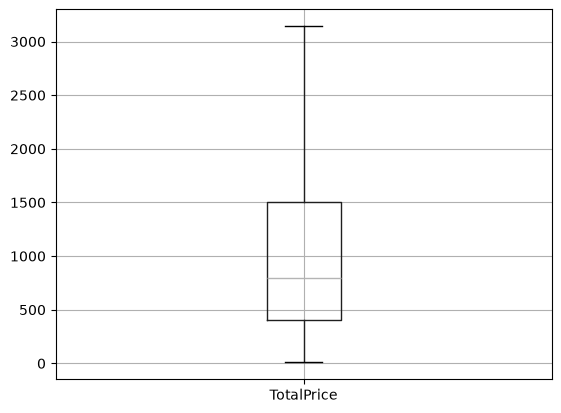

In [72]:
#Checking Oultiers in TotalPrice column
df.boxplot(column='TotalPrice')
plt.show()

In [73]:
Q1 = df['TotalPrice'].quantile(0.25)
Q3 = df['TotalPrice'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['TotalPrice'] < lower_bound) | (df['TotalPrice'] > upper_bound)]
print(f"Number of outliers: {len(outliers)}")
outliers

Number of outliers: 0


,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,...,TotalPrice,UsedCoupon,zscore,OrderMonth,OrderDayOfWeek,IsWeekend,CartConversionRatio,AvgItemPrice,CustomerOrderCount,ReferralAvgOrderValue


In [74]:
#Checking outliers in all columns
def find_outliers_iqr(col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return df[(df[col] < lower) | (df[col] > upper)]

numeric_cols = ['UnitPrice', 'Quantity', 'ItemsInCart', 'TotalPrice']
for col in numeric_cols:
    out = find_outliers_iqr(col)
    print(f"{col}: {len(out)} outliers")

UnitPrice: 0 outliers
Quantity: 0 outliers
ItemsInCart: 0 outliers
TotalPrice: 0 outliers


In [75]:
def remove_outliers_iqr(df, columns):
    """
    Removes outliers from specified numeric columns using the IQR method.
    
    Parameters:
        df (DataFrame): your dataset
        columns (list): list of column names to check for outliers
    
    Returns:
        DataFrame with outliers removed
    """
    df_clean = df.copy()
    
    for col in columns:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        
        before = len(df_clean)
        df_clean = df_clean[(df_clean[col] >= lower) & (df_clean[col] <= upper)]
        after = len(df_clean)
        
        print(f"{col}: removed {before - after} outliers")
    
    return df_clean

In [76]:
# For one column
df = remove_outliers_iqr(df, ['TotalPrice'])

# For multiple columns at once
df = remove_outliers_iqr(df, ['UnitPrice', 'Quantity', 'ItemsInCart', 'TotalPrice'])

print(f"Final row count: {len(df)}")

TotalPrice: removed 0 outliers
UnitPrice: removed 0 outliers
Quantity: removed 0 outliers
ItemsInCart: removed 0 outliers
TotalPrice: removed 0 outliers
Final row count: 1176


In [77]:
df = remove_outliers_iqr(df, ['TotalPrice'])   # ✅ correct — updates df
remove_outliers_iqr(df, ['TotalPrice'])        # ❌ wrong — result is discarded

TotalPrice: removed 0 outliers
TotalPrice: removed 0 outliers


,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,...,TotalPrice,UsedCoupon,zscore,OrderMonth,OrderDayOfWeek,IsWeekend,CartConversionRatio,AvgItemPrice,CustomerOrderCount,ReferralAvgOrderValue
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,...,2853.10,1,2.195362,1,2,0,0.714286,570.62,1,1036.421680
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,...,302.70,1,0.916723,8,4,0,0.666667,151.35,1,970.331014
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,...,2753.40,1,2.073705,2,1,0,0.625000,550.68,1,982.871399
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,...,273.19,1,0.952732,10,6,1,0.200000,273.19,1,1037.716892
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,...,2504.04,1,1.769427,5,3,0,0.500000,626.01,1,982.871399
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,ORD201195,2024-06-20,C21126,Desk,1,107.04,392 Main St,Credit Card,Cancelled,TRK38009181,...,107.04,1,1.155474,6,3,0,0.166667,107.04,1,1011.259790
1196,ORD201196,2024-03-04,C20095,Monitor,2,662.53,778 Main St,Online,Cancelled,TRK69207593,...,1325.06,1,0.330795,3,0,0,0.400000,662.53,1,1037.716892
1197,ORD201197,2023-07-13,C79674,Tablet,2,436.84,275 Main St,Online,Delivered,TRK88039356,...,873.68,1,0.219994,7,3,0,1.000000,436.84,1,1036.421680
1198,ORD201198,2024-08-22,C64753,Chair,4,262.52,509 Main St,Debit Card,Cancelled,TRK71683331,...,1050.08,1,0.004745,8,3,0,1.000000,262.52,1,1036.421680


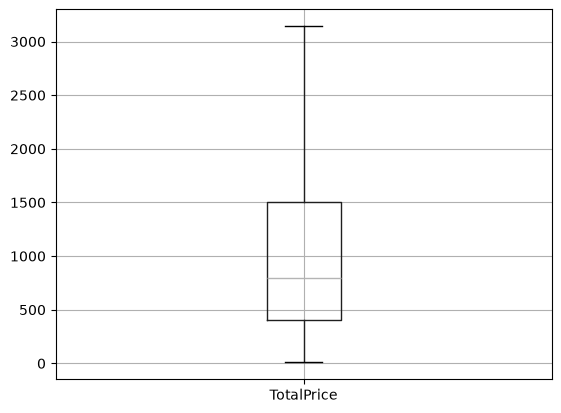

In [78]:
#Checking Oultiers in TotalPrice column
df.boxplot(column='TotalPrice')
plt.show()


In [79]:
Q1 = df['TotalPrice'].quantile(0.25)
Q3 = df['TotalPrice'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['TotalPrice'] < lower_bound) | (df['TotalPrice'] > upper_bound)]
print(f"Number of outliers: {len(outliers)}")
outliers

Number of outliers: 0


,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,...,TotalPrice,UsedCoupon,zscore,OrderMonth,OrderDayOfWeek,IsWeekend,CartConversionRatio,AvgItemPrice,CustomerOrderCount,ReferralAvgOrderValue


In [80]:
def remove_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return df[(df[col] >= lower) & (df[col] <= upper)]

# Use it and OVERWRITE df so the change actually sticks
print("Before:", len(df))
df = remove_outliers_iqr(df, 'TotalPrice')
print("After:", len(df))

Before: 1176
After: 1176


In [81]:
df['TotalPrice'].describe()

count    1176.000000
mean     1008.313359
std       762.542329
min        11.390000
25%       404.497500
50%       796.070000
75%      1506.367500
max      3143.700000
Name: TotalPrice, dtype: float64

In [82]:
Q1 = df['TotalPrice'].quantile(0.25)
Q3 = df['TotalPrice'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(f"Lower bound: {lower}, Upper bound: {upper}")
print(f"Outliers found: {len(df[(df['TotalPrice'] < lower) | (df['TotalPrice'] > upper)])}")

Lower bound: -1248.3075000000003, Upper bound: 3159.1725000000006
Outliers found: 0


In [83]:
print("Before:", len(df))
df = remove_outliers_iqr(df, 'TotalPrice')
print("After:", len(df))

Before: 1176
After: 1176


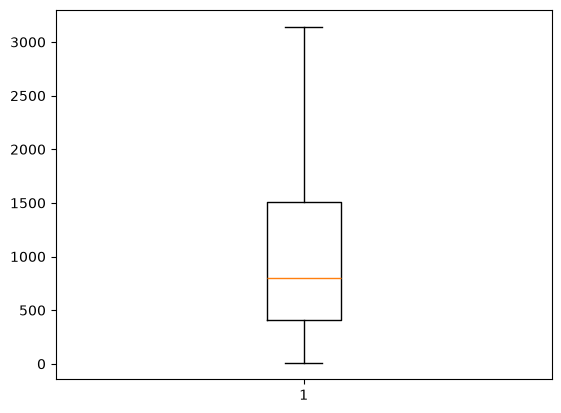

In [84]:
plt.boxplot(df['TotalPrice'])
plt.show()

In [85]:
df['Date'] = pd.to_datetime(df['Date'])
df['OrderDayOfWeek'] = df['Date'].dt.dayofweek
df['IsWeekend'] = df['OrderDayOfWeek'].isin([5, 6]).astype(int)

df['CartConversionRatio'] = df['Quantity'] / df['ItemsInCart']

df['CustomerOrderCount'] = df.groupby('CustomerID')['OrderID'].transform('count')

df['UsedCoupon'] = df['CouponCode'].notna().astype(int)

In [86]:
new_features = ['IsWeekend', 'CartConversionRatio', 'CustomerOrderCount', 'UsedCoupon']

correlations = df[new_features + ['TotalPrice']].corr()['TotalPrice'].sort_values(ascending=False)
print(correlations)

TotalPrice             1.000000
CartConversionRatio    0.224284
IsWeekend             -0.013594
CustomerOrderCount    -0.054822
UsedCoupon                  NaN
Name: TotalPrice, dtype: float64


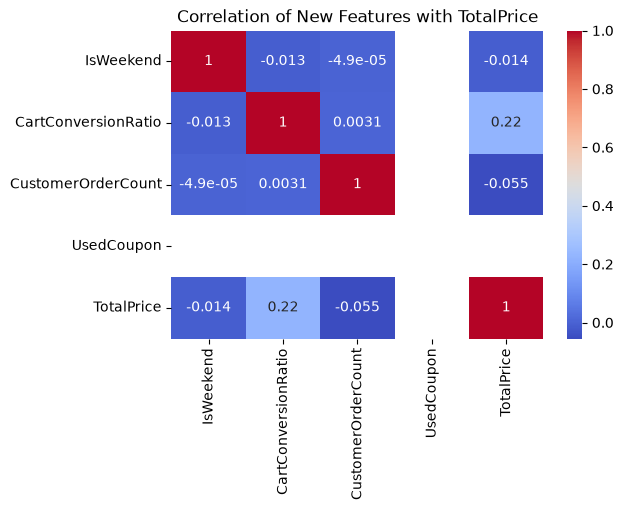

In [87]:
plt.figure(figsize=(6,4))
sns.heatmap(df[new_features + ['TotalPrice']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation of New Features with TotalPrice')
plt.show()

In [88]:
for feature in new_features:
    print(f"\n--- {feature} vs OrderStatus ---")
    print(df.groupby('OrderStatus')[feature].mean())


--- IsWeekend vs OrderStatus ---
OrderStatus
Cancelled    0.268595
Delivered    0.320000
Pending      0.257511
Returned     0.374486
Shipped      0.278970
Name: IsWeekend, dtype: float64

--- CartConversionRatio vs OrderStatus ---
OrderStatus
Cancelled    0.585627
Delivered    0.578891
Pending      0.591360
Returned     0.554830
Shipped      0.576487
Name: CartConversionRatio, dtype: float64

--- CustomerOrderCount vs OrderStatus ---
OrderStatus
Cancelled    1.012397
Delivered    1.008889
Pending      1.038627
Returned     1.004115
Shipped      1.021459
Name: CustomerOrderCount, dtype: float64

--- UsedCoupon vs OrderStatus ---
OrderStatus
Cancelled    1.0
Delivered    1.0
Pending      1.0
Returned     1.0
Shipped      1.0
Name: UsedCoupon, dtype: float64


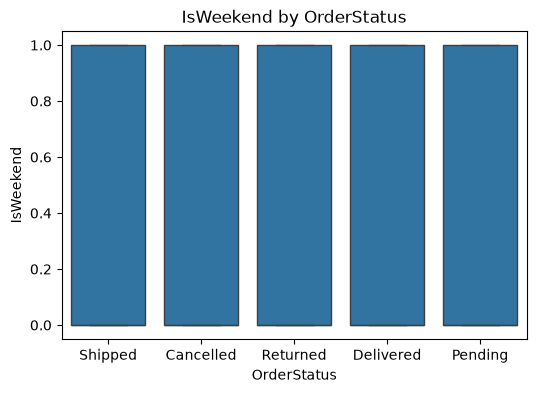

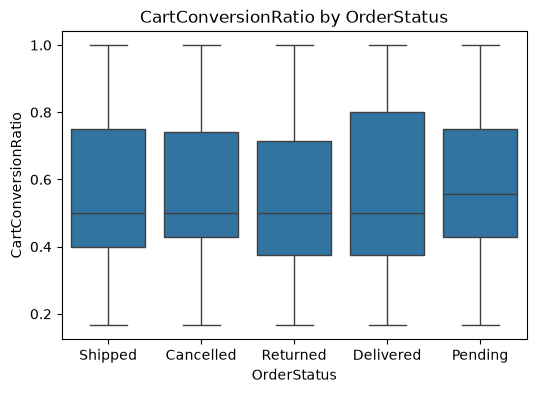

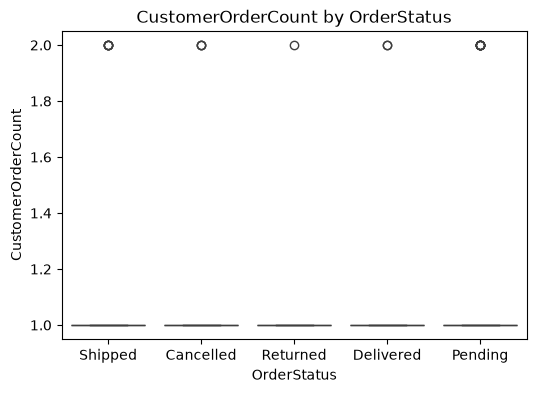

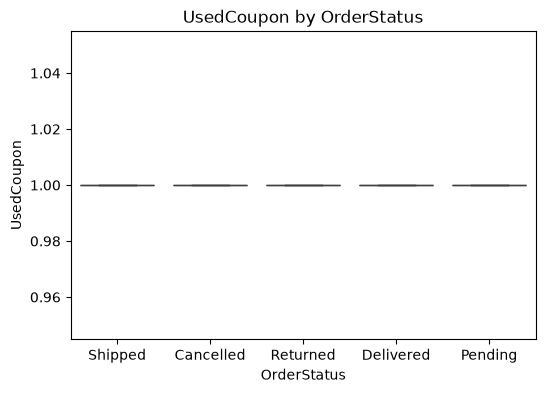

In [89]:
for feature in new_features:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='OrderStatus', y=feature, data=df)
    plt.title(f'{feature} by OrderStatus')
    plt.show()

In [94]:
df.to_csv("Cleaned Dataset for Data Analytics.csv", index=False)